# Model

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [38]:
df = pd.read_csv('cleaned_dataset.csv')

## Features

In [39]:
features = ["year", "month", "day", "dayofweek", "dayofyear"]

X = df[features]
y = df["temperature_celsius"]

## Train-Test Split

In [41]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [42]:
## Model 1 - Linear Regression

In [45]:
model = LinearRegression()
model.fit(X_train, y_train)

lr_pred = model.predict(X_test)

## Model 2 - Random Forest

In [46]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_test)

## Model 3 - Gradient Boosting

In [47]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()

gb.fit(X_train,y_train)

gb_pred = gb.predict(X_test)

## Model Evaluation

In [48]:
def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    print("="*40)
    print(name)
    print("="*40)
    print(f"MAE  : {mae:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R²   : {r2:.3f}")

    return [name, mae, rmse, r2]

In [49]:
results = []

results.append(evaluate_model("Linear Regression", y_test, lr_pred))

results.append(evaluate_model("Random Forest", y_test, rf_pred))

results.append(evaluate_model("Gradient Boosting", y_test, gb_pred))

Linear Regression
MAE  : 8.454
RMSE : 10.081
R²   : -0.065
Random Forest
MAE  : 7.808
RMSE : 9.661
R²   : 0.022
Gradient Boosting
MAE  : 7.741
RMSE : 9.553
R²   : 0.043


## Ensembel

In [51]:
ensemble_pred = (
    lr_pred +
    rf_pred +
    gb_pred
) / 3

In [52]:
results.append(
    evaluate_model(
        "Ensemble",
        y_test,
        ensemble_pred
    )
)

Ensemble
MAE  : 7.785
RMSE : 9.510
R²   : 0.052


## Model Comparison

In [53]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,8.453998,10.081399,-0.065277
1,Random Forest,7.808476,9.661287,0.021657
2,Gradient Boosting,7.740912,9.553233,0.043419
3,Ensemble,7.784862,9.510047,0.052048


In [54]:
results_df.sort_values(
    by="RMSE",
    ascending=True
)

,Model,MAE,RMSE,R2 Score
3,Ensemble,7.784862,9.510047,0.052048
2,Gradient Boosting,7.740912,9.553233,0.043419
1,Random Forest,7.808476,9.661287,0.021657
0,Linear Regression,8.453998,10.081399,-0.065277


C:\Users\Purvi jain\AppData\Local\Temp\ipykernel_23520\3962301135.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


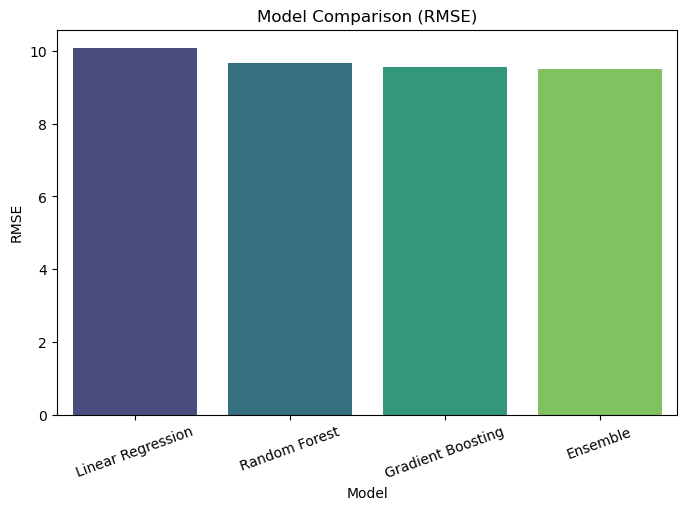

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE",
    palette="viridis"
)

plt.title("Model Comparison (RMSE)")
plt.xticks(rotation=20)

plt.show()

C:\Users\Purvi jain\AppData\Local\Temp\ipykernel_23520\2273871362.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


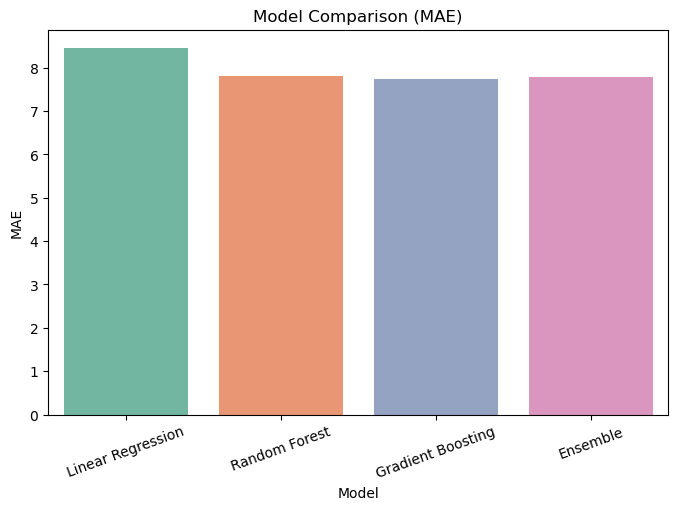

In [56]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="MAE",
    palette="Set2"
)

plt.title("Model Comparison (MAE)")
plt.xticks(rotation=20)

plt.show()

C:\Users\Purvi jain\AppData\Local\Temp\ipykernel_23520\2464781728.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


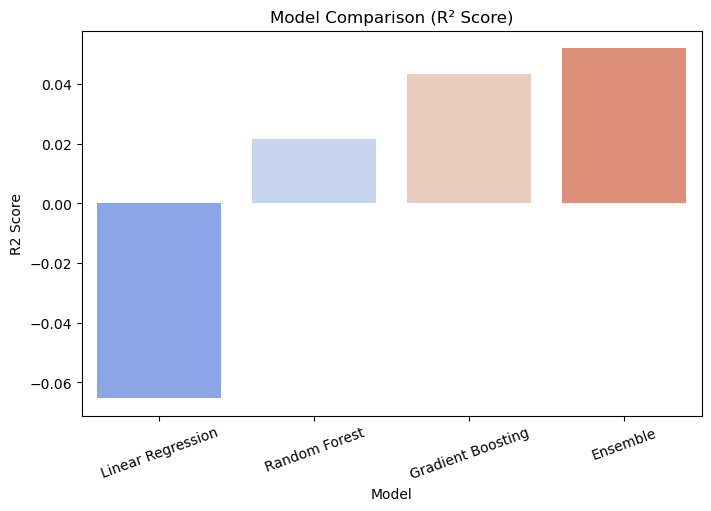

In [57]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score",
    palette="coolwarm"
)

plt.title("Model Comparison (R² Score)")
plt.xticks(rotation=20)

plt.show()

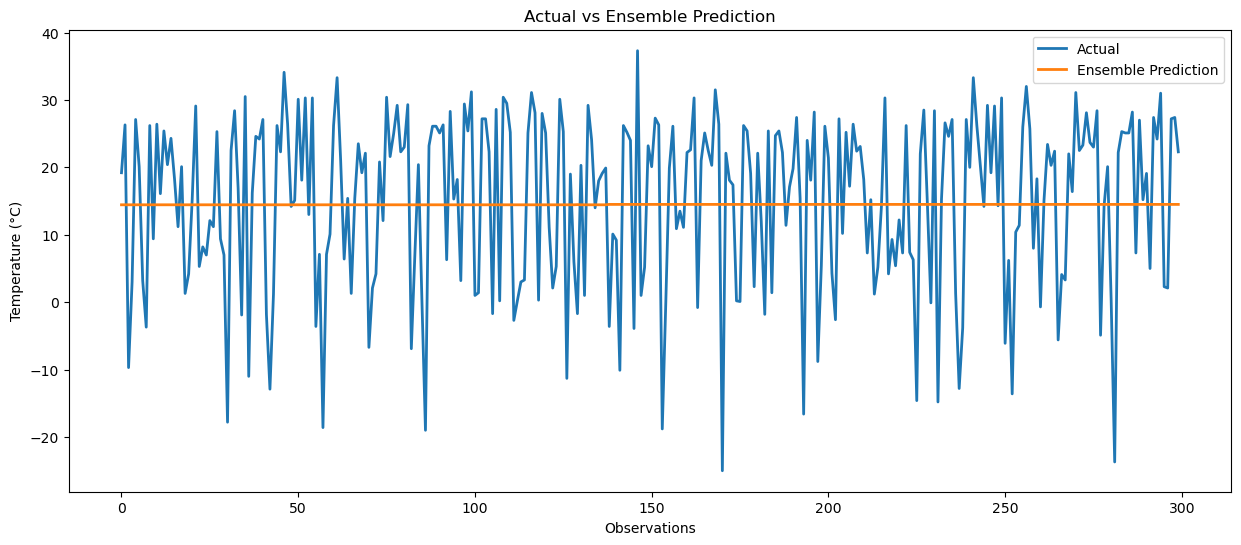

In [58]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.values[:300],
    label="Actual",
    linewidth=2
)

plt.plot(
    ensemble_pred[:300],
    label="Ensemble Prediction",
    linewidth=2
)

plt.legend()

plt.title("Actual vs Ensemble Prediction")

plt.xlabel("Observations")

plt.ylabel("Temperature (°C)")

plt.show()

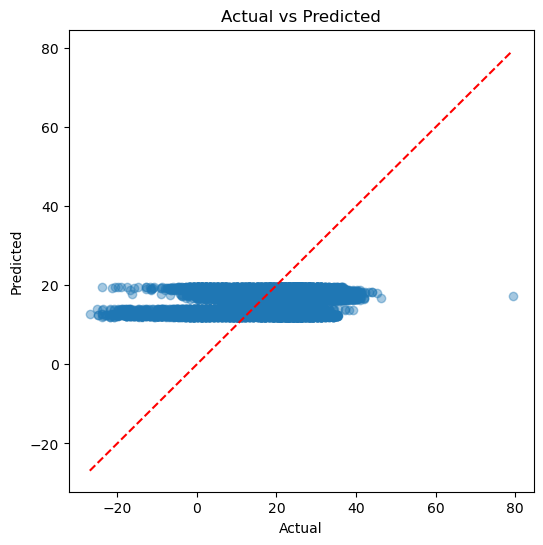

In [59]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()